# **Project Title**
# **Google Play Store Apps and User Reviews Analysis using Python and PowerBi**


**GitHub Link-**  https://github.com/Vidya-lamkhade/Transforming-EDAs-to-dashboards-Playstore-analysis


**1. Objective:**

The objective of this project is to analyze the Google Play Store applications and user reviews to understand:

* App distribution across categories
* User ratings and reviews
* Free vs Paid app trends
* User sentiment (Positive, Neutral, Negative)
* Relationship between sentiment polarity and subjectivity
* Top performing app categories

The project helps stakeholders identify which app categories perform well and how users react to applications.



**2. Problem Statement**

The Google Play Store contains thousands of applications from different categories. This project aims to analyze the dataset to understand app performance and user behavior. The analysis focuses on identifying the categories with the highest installs, calculating the average app ratings, comparing Free and Paid apps, finding the most reviewed applications, analyzing user sentiment distribution, determining which categories receive the most positive reviews, and studying the relationship between sentiment polarity and subjectivity. The insights obtained help developers and businesses make informed decisions and improve user experience.

**3.Tools and Technologies used**

Python ---> Data Cleaning and Analysis

Pandas---> Data Manipulation

NumPy ---> Numerical Operations

Matplotlib --->	Data Visualization

Seaborn --->Statistical Visualization

Google Colab ---> Python Environment

Power Bi --->Dashboard Development

DAX ---> Measures and KPIs

Power Query ---> Data Transformation

**4. Import Libraries**

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

**5. Load Dataset**

**Dataset Description**

This project uses two datasets:

**PlayStore Dataset**

The dataset contains information about applications available on the Google Play Store.

Key Features:
- App
- Category
- Rating
- Reviews
- Installs
- Type
- Price
- Content Rating
- Genres
- Last Updated
- Android Version

**User Reviews Dataset**
This dataset contains customer reviews and sentiment analysis results.

Key Features:
- App
- Sentiment
- Sentiment Polarity
- Sentiment Subjectivity

In [ ]:
playstore=pd.read_csv("PlayStore.csv")
reviews=pd.read_csv("UserReviews.csv")

**5. Data Cleaning & Transformation**

The following steps were performed:

**PlayStoreData**
* Removed duplicate records.
* Converted Installs column:
* Removed '+' and ',' symbols.
* Converted to numeric datatype.
* Converted Price column:
* Removed '$' sign.
* Converted to decimal.
* Converted Reviews column to integer.
* Handled missing values in Rating column.
* Converted Last Updated into Date datatype.

**UserReviewsData**
* Removed null reviews.
* Removed duplicate reviews.
* Checked missing sentiment values.
* Converted Sentiment Polarity to numeric.
* Converted Sentiment Subjectivity to numeric.

In [ ]:
# Display first 5 rows
playstore.head()
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
# Check Shape
print("Play Store Shape :", playstore.shape)
print("Reviews Shape :", reviews.shape)

Play Store Shape : (10841, 13)
Reviews Shape : (64295, 5)


**6. Data Understanding**

***Dataset Information***


In [ ]:
playstore.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


***Statistical Summary***


In [ ]:
playstore.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [ ]:
reviews.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


***Missing Values***

In [ ]:
playstore.isnull().sum()


,0
App,0
Category,0
Rating,1465
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
reviews.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


**7. Data Cleaning**

**Step 1: Remove Duplicates**

In [ ]:
playstore.drop_duplicates(inplace=True)

In [ ]:
playstore.duplicated().sum()

np.int64(0)

In [ ]:
reviews.drop_duplicates(inplace=True)

In [ ]:
reviews.duplicated().sum()

np.int64(0)

**Step 2: Handle Missing Values**

Rating

In [ ]:
playstore['Rating'].isnull().sum()

np.int64(1465)

In [ ]:
# Fill missing ratings with median.
playstore['Rating'] = playstore['Rating'].fillna(playstore['Rating'].median())

In [ ]:
playstore['Rating'].isnull().sum()

np.int64(0)

**Step 3: Clean Review Column**

In [ ]:
# Convert object to numeric
playstore['Reviews'] = pd.to_numeric(playstore['Reviews'], errors='coerce')

**Step 4: Clean Size Column**

The Size column usually contains:

19M

25M

14k

Varies with device

In [ ]:
def clean_size(x):
    if pd.isna(x):
        return None

    x = str(x)

    if 'M' in x:
        return float(x.replace('M',''))

    elif 'k' in x:
        return float(x.replace('k',''))/1024

    else:
        return None

playstore['Size_MB'] = playstore['Size'].apply(clean_size)

Then remove the original Size column

In [ ]:
playstore.drop('Size', axis=1, inplace=True)

In [ ]:
playstore.head()

,App,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


**Step 5: Clean Installs Column**


Before:

1,000+

10,000+

1,000,000+

After:

1000

10000

1000000

In [ ]:
playstore['Installs'] = playstore['Installs'].str.replace(',','')

playstore['Installs'] = playstore['Installs'].str.replace('+','')

playstore['Installs'] = pd.to_numeric(playstore['Installs'], errors='coerce')

In [ ]:
playstore.head()

,App,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,10000.0,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,500000.0,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,5000000.0,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,50000000.0,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,100000.0,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


**Step 6: Clean Price Column**

Before:

$0.99

$4.99

After:

0.99

4.99

In [ ]:
playstore['Price'] = playstore['Price'].str.replace('$','')
playstore['Price'] = pd.to_numeric(playstore['Price'],errors='coerce')

In [ ]:
playstore.head()

,App,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


**Step 7: Convert Date Column**

In [ ]:
playstore['Last Updated'] = pd.to_datetime(
    playstore['Last Updated'],
    errors='coerce'
)

In [ ]:
playstore.head()

,App,Category,Rating,Reviews,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8


**Step 8: User Reviews Dataset**

In [ ]:
# Returns total count of missing values per column
reviews.isnull().sum()

,0
App,0
Translated_Review,987
Sentiment,982
Sentiment_Polarity,982
Sentiment_Subjectivity,982


In [ ]:
#Remove missing values.
reviews.dropna(inplace=True)

In [ ]:
reviews.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


**Convert sentiment columns into numeric.**

In [ ]:
reviews['Sentiment_Polarity'] = pd.to_numeric(
    reviews['Sentiment_Polarity'],
    errors='coerce'
)

reviews['Sentiment_Subjectivity'] = pd.to_numeric(
    reviews['Sentiment_Subjectivity'],
    errors='coerce'
)

**8. Final Dataset Check**

In [ ]:
playstore.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10358 non-null  object        
 1   Category        10358 non-null  object        
 2   Rating          10358 non-null  float64       
 3   Reviews         10357 non-null  float64       
 4   Installs        10357 non-null  float64       
 5   Type            10357 non-null  object        
 6   Price           10357 non-null  float64       
 7   Content Rating  10357 non-null  object        
 8   Genres          10358 non-null  object        
 9   Last Updated    10357 non-null  datetime64[ns]
 10  Current Ver     10350 non-null  object        
 11  Android Ver     10355 non-null  object        
 12  Size_MB         8831 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(7)
memory usage: 1.1+ MB


In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29692 entries, 0 to 64230
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29692 non-null  object 
 1   Translated_Review       29692 non-null  object 
 2   Sentiment               29692 non-null  object 
 3   Sentiment_Polarity      29692 non-null  float64
 4   Sentiment_Subjectivity  29692 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.4+ MB


In [ ]:
playstore.isnull().sum()


,0
App,0
Category,0
Rating,0
Reviews,1
Installs,1
Type,1
Price,1
Content Rating,1
Genres,0
Last Updated,1


In [ ]:
reviews.isnull().sum()


,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


**9. Exploratory Data Analysis (EDA)**
The analysis was performed in three stages:

**A). Univariate Analysis**

Purpose: Understand the distribution of individual variables.

Visualization:
* Count Plot of Categories
* Distribution of Ratings
* Free vs Paid Apps Pie Chart
* Sentiment Distribution Pie Chart

**Insights:**
* Most applications are Free.
* Ratings are concentrated around 4 to 4.5.
* Positive reviews dominate the dataset.

**B. Bivariate Analysis**

Purpose:Study relationships between two variables.

Visualization:

* Reviews vs Ratings Bubble Chart
* Average Rating by Category
* Installs by Category
* Average Rating by Year

**Insights**
* Categories with high installs do not always have the highest ratings.
* Some apps receive millions of reviews while maintaining high ratings.

**Multivariate Analysis**

Purpose:Study multiple variables simultaneously.

Visualization:

* Category-wise Sentiment Analysis
* Sentiment Polarity vs Subjectivity Scatter Plot
* Reviews, Ratings, and Installs Bubble Chart

**Insights**
* Positive reviews have higher polarity values.
* Gaming and Family categories receive a large number of positive reviews.
* Subjectivity varies significantly across sentiments.






***Visualization 1***

**A Histogram Plot (Histplot)** is used to visualize the distribution of numerical data by dividing the data into intervals called bins and showing the frequency of observations in each bin.

***Distribution of Ratings***

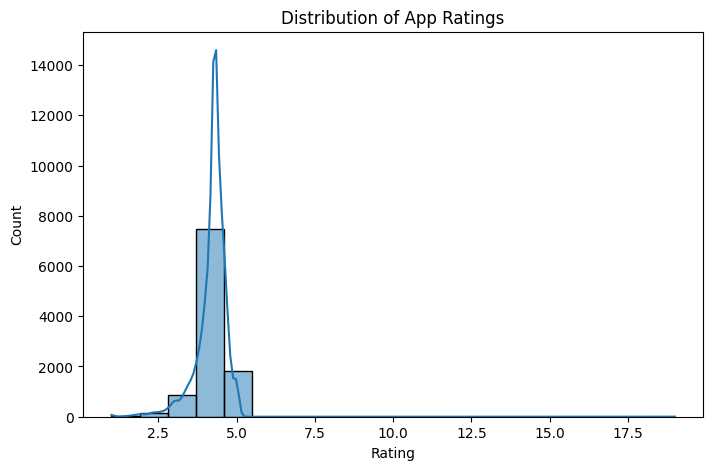

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    playstore['Rating'],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")

plt.show()

***Insight***
* Most apps have ratings between 4.0 & 4.5.

***Visualization 2***

**Bar Chart**
This bar chart is used to visualize the top 10 categories in the Google Play Store based on the number of applications available in each category. It helps identify which categories dominate the Play Store ecosystem.

***Top app Categories***

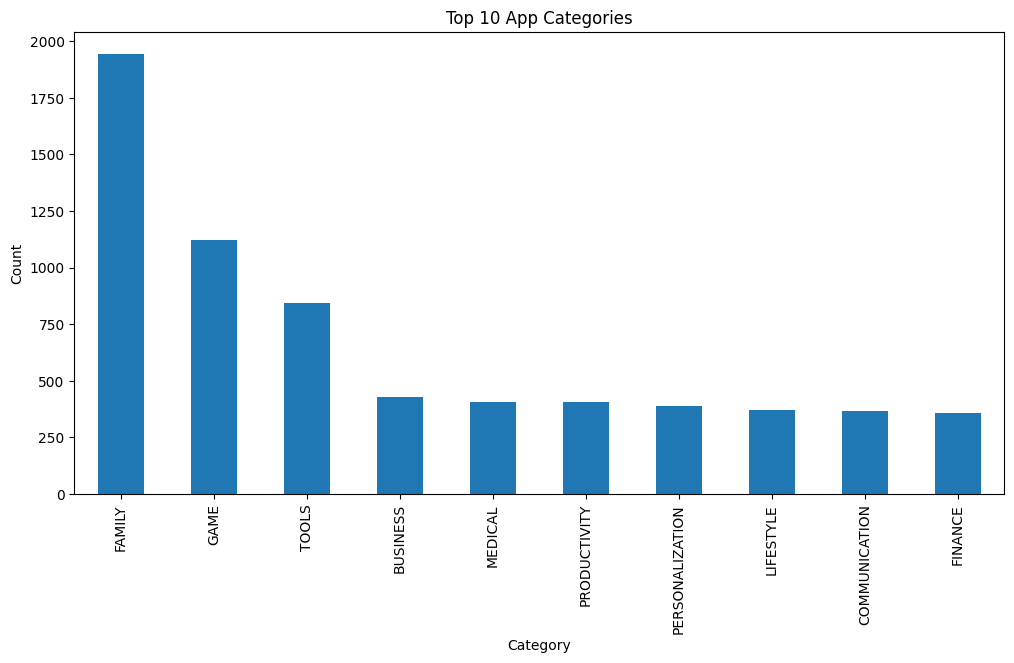

In [ ]:
plt.figure(figsize=(12,6))

playstore['Category'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 App Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

***Insight***
* Family, Game and Tools have the highest number of applications.

***Visualization 3***

**Pie Chart**

A Pie Chart is used to represent the proportion of different categories as parts of a whole. In this project, pie charts are used to visualize the distribution of Free vs Paid applications and the distribution of user sentiments (Positive, Neutral, and Negative). Each slice of the pie represents the percentage share of a category, making it easy to compare their relative contributions and understand the overall composition of the dataset.

***Free vs Paid Apps***

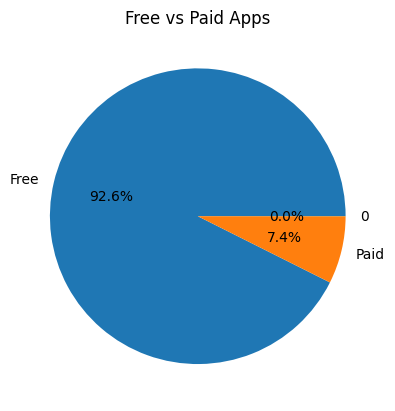

In [ ]:
playstore['Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Free vs Paid Apps")

plt.ylabel('')

plt.show()

***Insight***
* Most apps are free.

***Visualization 4***

**Scatter Plot**

A Scatter Plot is used to visualize the relationship between two numerical variables. In this project, the scatter plot is used to analyze the relationship between the number of reviews and the ratings of applications on the Google Play Store. Each point in the plot represents an application, where the x-axis shows the number of reviews and the y-axis shows the rating. This visualization helps identify whether applications with a higher number of reviews tend to have higher or lower ratings and reveals any correlation between user engagement and app quality.

***Reviews vs Rating***

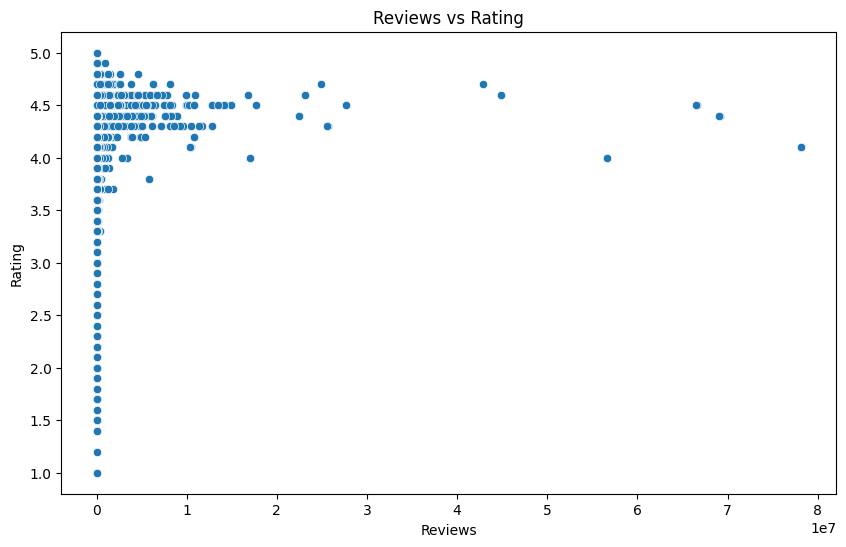

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=playstore,
    x='Reviews',
    y='Rating'
)

plt.title("Reviews vs Rating")

plt.show()

***Insight***
* Apps with more reviews tend to have good rating

***Visualization 5***

***Average Rating by Category***

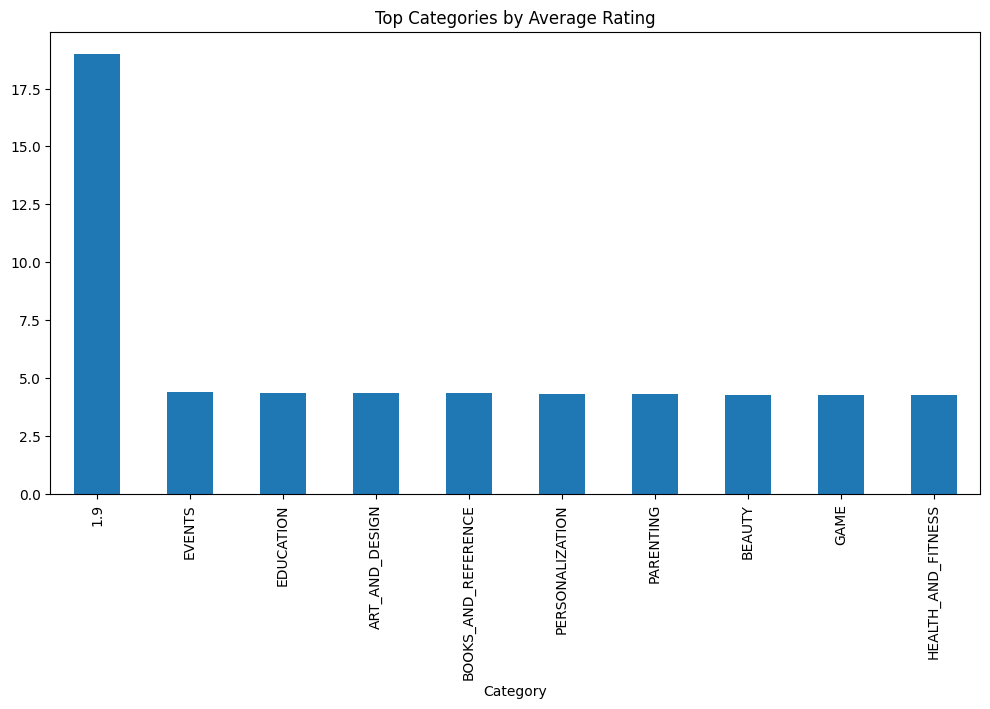

In [ ]:
avg_rating = playstore.groupby(
    'Category'
)['Rating'].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

avg_rating.plot(kind='bar')

plt.title("Top Categories by Average Rating")

plt.show()

***Insight***
* Education and Events categories have high ratings.

***Visualization 6***

**Heatmap**

A Heatmap is used to visualize the correlation between numerical variables in the dataset. In this project, the heatmap is created using the features Rating, Reviews, Installs, and Price to understand how these variables are related to each other. The color intensity represents the strength of the correlation, where values close to +1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values near 0 indicate little or no correlation. This visualization helps identify patterns such as whether highly reviewed apps tend to have more installs or whether app price affects ratings.

***Correlation Heatmap***

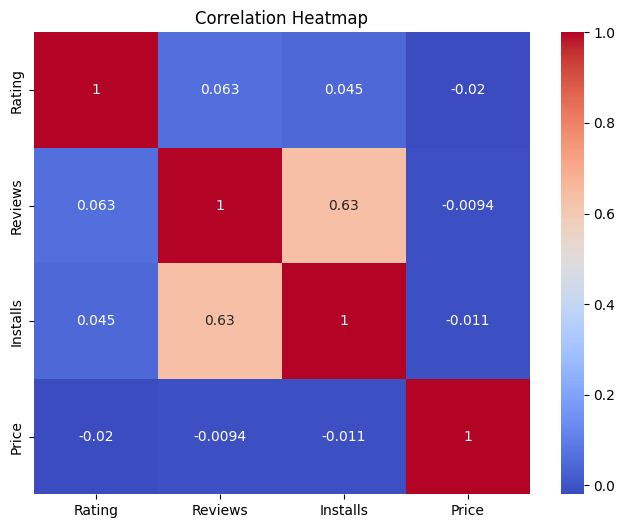

In [ ]:
corr = playstore[
[
'Rating',
'Reviews',
'Installs',
'Price'
]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

***Insight***
* Reviews and Installs are positively correlated.

***Visualization 7***

***Sentiment Distribution***

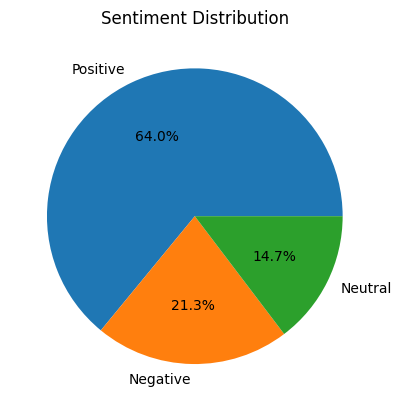

In [ ]:
reviews['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution")

plt.ylabel('')

plt.show()

***Insight***
* Positive reviews dominate

***Visualization 8***

***Sentiment Polarity Distribution***

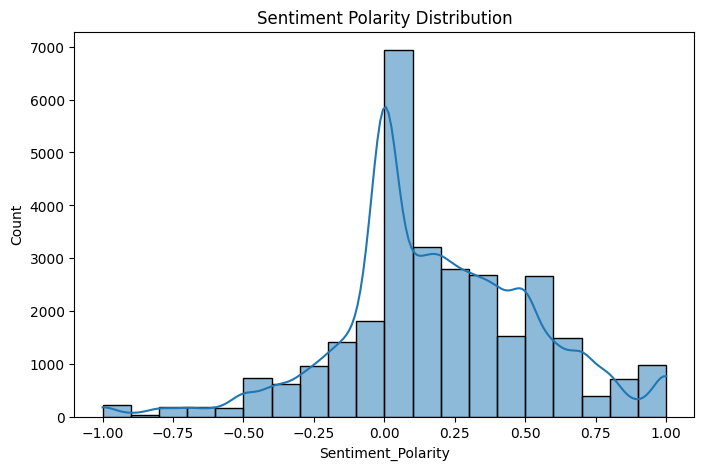

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    reviews['Sentiment_Polarity'],
    bins=20,
    kde=True
)

plt.title("Sentiment Polarity Distribution")

plt.show()

***10. Download the file in Google Colab***

In [ ]:
playstore.to_csv('PlayStoreData.csv', index=False)

reviews.to_csv('UserReviewsData.csv', index=False)

In [ ]:
from google.colab import files

files.download('PlayStoreData.csv')
files.download('UserReviewsData.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**11.Business Insights**

***Insight 1***

* Gaming and Family categories dominate the Play Store.

***Insight 2***

* More than 90% of applications are Free.

***Insight 3***

* Education and Events categories have the highest ratings.

***Insight 4***

* Positive sentiment dominates user reviews.

***Insight 5***

* Reviews and Installs are positively correlated, indicating that popular apps receive more engagement.

**11) Conclusion**

This project successfully transformed raw Google Play Store data into meaningful business insights using Exploratory Data Analysis.

The analysis identified the most popular app categories, user sentiment trends, installation patterns, and pricing strategies. The insights were further converted into an interactive Power BI dashboard, enabling stakeholders to make data-driven decisions.

Overall, this project demonstrates the complete analytics workflow, from data preprocessing and visualization to business storytelling and dashboard development.

**12.Future Scope**

Future improvements include:

- Machine Learning for Rating Prediction

- Install Prediction Models

- NLP-based Sentiment Classification

- Recommendation System

- Real-time Dashboard using APIs

- Deployment using Streamlit

- Power BI Service Integration